In [1]:
from parsing_library import * 

In [6]:
import os
import json
import numpy as np
from parsing_library import *

DATA_SIZES = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 500000, 1000000]

def calculate_average_rmse(data_folder, fit_folder, experiment_ids, estimator, fit_folder_base_name, base_data_name, data_sizes):
    rmse_results = {size: [] for size in data_sizes}

    for experiment_id in experiment_ids:
        print(f"Processing experiment ID: {experiment_id}")
        
        for size in data_sizes:
            print(f"Processing data size: {size}")
            
            data_path = os.path.join(data_folder, base_data_name % experiment_id)
            with open(data_path) as f:
                data = json.load(f)

            true_theta = np.array(data['theta'])
            vocabulary = data['vocabulary']

            if estimator == 'gibbs':
                fit_path = fit_folder
            else:
                fit_path = os.path.join(fit_folder, estimator, fit_folder_base_name % experiment_id)

            if estimator == 'vi':
                fit = load_fit_by_size(size, fit_path)
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary, D=true_theta.shape[1])
                num_samples = estimated_word_vectors.shape[2]
            elif estimator == 'hmc':
                fit = load_fit_by_size(size, fit_path)
                estimated_word_vectors = fit['word_vectors']
                estimated_context_vectors = fit['context_vectors']
                num_samples = estimated_word_vectors.shape[2]
            elif estimator in ('laplace', 'map'):
                fit = load_fit_by_size(size, fit_path)
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.optimized_params_pd, vocabulary, D=true_theta.shape[1])
                num_samples = 1
            elif estimator == 'gibbs':
                df = load_gibbs_by_size_and_experiment(fit_path, fit_folder_base_name, size, experiment_id)
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_gibbs_from_df(df, vocabulary, D=true_theta.shape[1])
                num_samples = estimated_word_vectors.shape[2]

            theta_combined = np.concatenate((estimated_word_vectors, estimated_context_vectors), axis=0)
            theta_samples = np.moveaxis(theta_combined, 2, 0)

            # Calculate RMSE
            rmse = calculate_rmse(theta_samples, true_theta, vocabulary)
            rmse_results[size].append(rmse)

    # Calculate average RMSE for each data size
    average_rmse = {size: np.mean(rmse_results[size]) for size in data_sizes}

    return average_rmse#, rmse_results

In [9]:

data_folder = "../../data/ten_V100K5"
fit_folder = "../../results_ten_V100K5/nofix"
estimator = "hmc"

experiment_ids = [1,2,3,4,5,6,7,8,9,10]

fit_folder_base_name="%i"
base_data_name="%i.json"

data_sizes =  [1000, 2000, 5000, 10000, 20000, 50000, 100000, 500000, 1000000]

average_rmse_hmc = calculate_average_rmse(data_folder, fit_folder, experiment_ids, estimator, fit_folder_base_name, base_data_name, data_sizes)

Processing experiment ID: 1
Processing data size: 1000
Processing data size: 2000
Processing data size: 5000
Processing data size: 10000
Processing data size: 20000
Processing data size: 50000
Processing data size: 100000
Processing data size: 500000
Processing data size: 1000000
Processing experiment ID: 2
Processing data size: 1000
Processing data size: 2000
Processing data size: 5000
Processing data size: 10000
Processing data size: 20000
Processing data size: 50000
Processing data size: 100000
Processing data size: 500000
Processing data size: 1000000
Processing experiment ID: 3
Processing data size: 1000
Processing data size: 2000
Processing data size: 5000
Processing data size: 10000
Processing data size: 20000
Processing data size: 50000
Processing data size: 100000
Processing data size: 500000
Processing data size: 1000000
Processing experiment ID: 4
Processing data size: 1000
Processing data size: 2000
Processing data size: 5000
Processing data size: 10000
Processing data size

In [10]:

data_folder = "../../data/ten_V100K5"
fit_folder = "../../results_ten_V100K5/nofix"
estimator = "vi"

experiment_ids = [1,2,3,4,5,6,7,8,9,10]

fit_folder_base_name="%i"
base_data_name="%i.json"

data_sizes =  [1000, 2000, 5000, 10000, 20000, 50000, 100000, 500000, 1000000]

average_rmse_vi = calculate_average_rmse(data_folder, fit_folder, experiment_ids, estimator, fit_folder_base_name, base_data_name, data_sizes)

Processing experiment ID: 1
Processing data size: 1000
Processing data size: 2000
Processing data size: 5000
Processing data size: 10000
Processing data size: 20000
Processing data size: 50000
Processing data size: 100000
Processing data size: 500000
Processing data size: 1000000
Processing experiment ID: 2
Processing data size: 1000
Processing data size: 2000
Processing data size: 5000
Processing data size: 10000
Processing data size: 20000
Processing data size: 50000
Processing data size: 100000
Processing data size: 500000
Processing data size: 1000000
Processing experiment ID: 3
Processing data size: 1000
Processing data size: 2000
Processing data size: 5000
Processing data size: 10000
Processing data size: 20000
Processing data size: 50000
Processing data size: 100000
Processing data size: 500000
Processing data size: 1000000
Processing experiment ID: 4
Processing data size: 1000
Processing data size: 2000
Processing data size: 5000
Processing data size: 10000
Processing data size

In [14]:

data_folder = "../../data/ten_V100K5"
fit_folder = "../../results/alvis-results"
estimator = "gibbs"

experiment_ids = [1, 10]

fit_folder_base_name="gibbs-samples-N-%i-D-5-%i.csv"
base_data_name="%i.json"

data_sizes =  [1000, 2000, 5000, 10000, 20000, 50000, 100000]

average_rmse_gibbs = calculate_average_rmse(data_folder, fit_folder, experiment_ids, estimator, fit_folder_base_name, base_data_name, data_sizes)

Processing experiment ID: 1
Processing data size: 1000
Processing data size: 2000
Processing data size: 5000
Processing data size: 10000
Processing data size: 20000
Processing data size: 50000
Processing data size: 100000
Processing experiment ID: 10
Processing data size: 1000
Processing data size: 2000
Processing data size: 5000
Processing data size: 10000
Processing data size: 20000
Processing data size: 50000
Processing data size: 100000


In [15]:
x = [1]
x.append(2)
x

[1, 2]

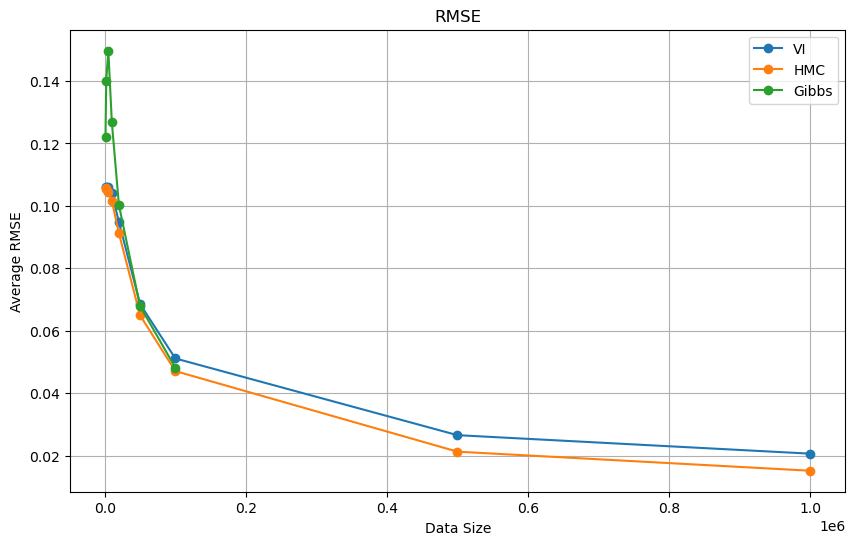

In [16]:
data_sizes = list(average_rmse_vi.keys())
rmse_vi = list(average_rmse_vi.values())
rmse_hmc = list(average_rmse_hmc.values())
rmse_gibbs = list(average_rmse_gibbs.values())
rmse_gibbs.append(None)
rmse_gibbs.append(None)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(data_sizes, rmse_vi, marker='o', label='VI')
plt.plot(data_sizes, rmse_hmc, marker='o', label='HMC')
plt.plot(data_sizes, rmse_gibbs, marker='o', label='Gibbs')

# Add labels and title
plt.xlabel('Data Size')
plt.ylabel('Average RMSE')
plt.title('RMSE')
#plt.xscale('log')  # Use logarithmic scale for data sizes
plt.legend()
plt.grid(True)

# Show plot
plt.show()